**1)Apply convolution on a custom image and show the results. Then, apply max-pooling, depth-wise pooling, and average pooling on the images from the previous step and show the results.**


Saving img1.tif to img1 (1).tif
Uploaded file: img1 (1).tif


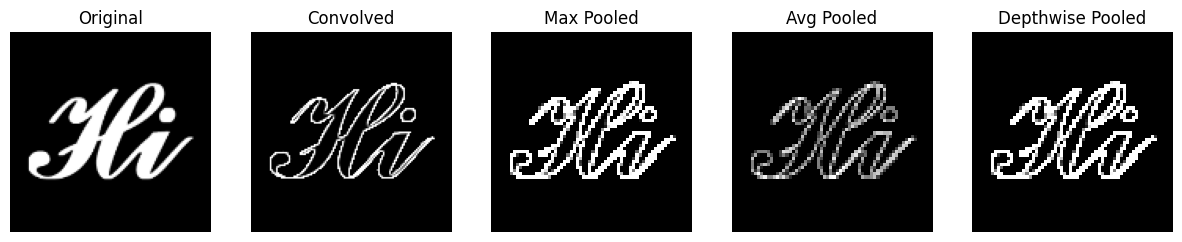

In [ ]:
# Full Colab-compatible image processing code

import cv2
import numpy as np
import tensorflow as tf #for depthwise pooling
import matplotlib.pyplot as plt
from google.colab import files

# Step 1: Upload the image
uploaded = files.upload()  # Upload any image file

if len(uploaded) == 0:
    raise ValueError("No file uploaded!")

file_name = list(uploaded.keys())[0]
print(f"Uploaded file: {file_name}")

# Step 2: Read image in grayscale
image = cv2.imread(file_name, cv2.IMREAD_GRAYSCALE)
if image is None:
    raise ValueError("Failed to load image. Make sure it is a valid image file.")

# Step 3: Resize to 128x128
image = cv2.resize(image, (128, 128))

# Step 4: Apply convolution with an edge-detection kernel #3x3 kernel detects boundary in an image
kernel = np.array([[-1, -1, -1],
                   [-1,  8, -1],
                   [-1, -1, -1]])
convolved_image = cv2.filter2D(image, -1, kernel) #showing edges

# Step 5: Max pooling function
def max_pooling(img, pool_size=2):
    h, w = img.shape
    new_h, new_w = h // pool_size, w // pool_size
    pooled_img = np.zeros((new_h, new_w))

    for i in range(new_h):
        for j in range(new_w):
            pooled_img[i, j] = np.max(img[i * pool_size:(i + 1) * pool_size, j * pool_size:(j + 1) * pool_size])

    return pooled_img

max_pooled = max_pooling(convolved_image)

# Step 6: Average pooling using cv2.resize
avg_pooled = cv2.resize(convolved_image, (64, 64), interpolation=cv2.INTER_AREA)

# Step 7: Depthwise pooling using TensorFlow
image_tensor = tf.convert_to_tensor(convolved_image, dtype=tf.float32)
image_tensor = tf.expand_dims(tf.expand_dims(image_tensor, axis=0), axis=-1)  # Shape: [1, H, W, 1]
depthwise_pooled = tf.nn.pool(image_tensor, window_shape=[2, 2], pooling_type='MAX', strides=[2, 2])
depthwise_pooled = tf.squeeze(depthwise_pooled).numpy()  # Remove extra dimensions

# Step 8: Display all images
fig, axes = plt.subplots(1, 5, figsize=(15, 6))
titles = ["Original", "Convolved", "Max Pooled", "Avg Pooled", "Depthwise Pooled"]
images = [image, convolved_image, max_pooled, avg_pooled, depthwise_pooled]

for ax, img, title in zip(axes, images, titles):
    ax.imshow(img, cmap="gray")
    ax.set_title(title)
    ax.axis("off")

plt.show()


2)In previous labs, you created a fully connected network for classifying the MNIST Fashion dataset. Now, create and train a convolutional neural network for the same dataset and compare the results of the CNN and FCN

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 23s 10ms/step - accuracy: 0.7946 - loss: 0.5780 - val_accuracy: 0.8536 - val_loss: 0.4049
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 21s 11ms/step - accuracy: 0.8661 - loss: 0.3648 - val_accuracy: 0.8552 - val_loss: 0.3994
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 20s 10ms/step - accuracy: 0.8810 - loss: 0.3248 - val_accuracy: 0.8749 - val_loss: 0.3450
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 21s 11ms/step - accuracy: 0.8896 - loss: 0.2952 - val_accuracy: 0.8766 - val_loss: 0.3362
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 20s 11ms/step - accuracy: 0.8979 - loss: 0.2727 - val_accuracy: 0.8705 - val_loss: 0.3664
Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 21s 11ms/step - accuracy: 0.9041 - loss: 0.2586 - val_accuracy: 0.8779 - val_loss: 0.3557
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 19s 10ms/step - accuracy: 0.9054 - loss: 0.2482 - val_accuracy: 0.8874 - val_loss: 0.3325
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 22s 12ms/step - accuracy: 0.9086 - loss: 0

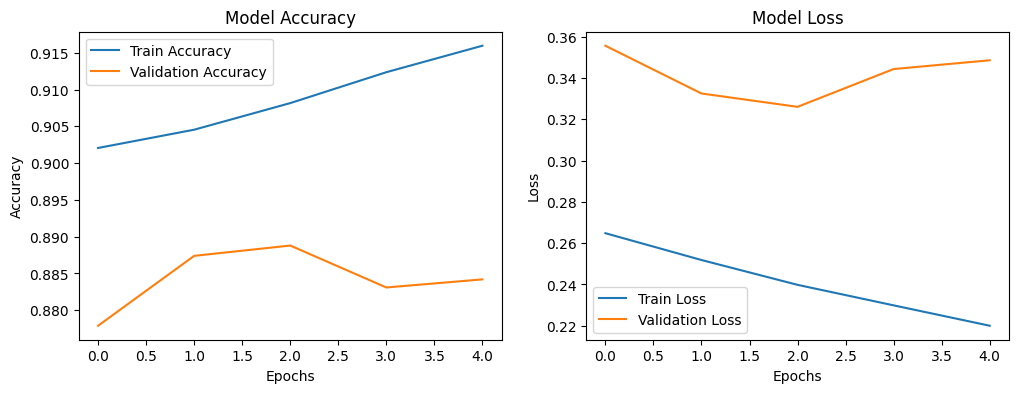

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


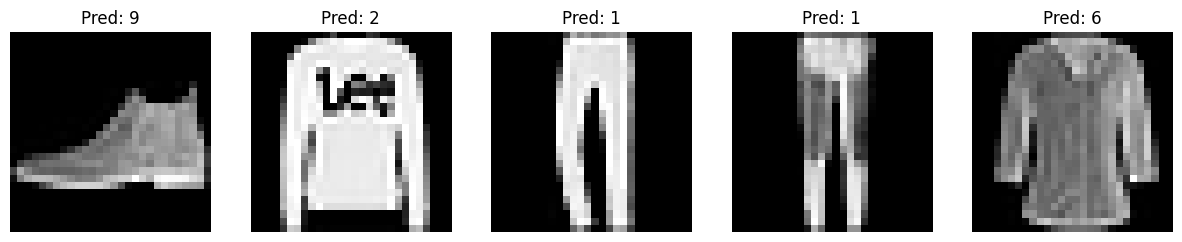

In [ ]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

(x_train, y_train), (x_test, y_test) = keras.datasets.fashion_mnist.load_data()
x_train, x_test = x_train / 255.0, x_test / 255.0

x_train_flat = x_train.reshape(-1, 28*28)
x_test_flat = x_test.reshape(-1, 28*28)

fcn_model = keras.Sequential([
    layers.Dense(512, activation="relu", input_shape=(28*28,)),
    layers.Dense(256, activation="relu"),
    layers.Dense(10, activation="softmax")
])

fcn_model.compile(optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"])
fcn_model.fit(x_train_flat, y_train, epochs=5, validation_data=(x_test_flat, y_test))
history = fcn_model.fit(x_train_flat, y_train, epochs=5, validation_data=(x_test_flat, y_test))

plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.title('Model Accuracy')

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.title('Model Loss')

plt.show()

predictions = fcn_model.predict(x_test_flat)

fig, axes = plt.subplots(1, 5, figsize=(15, 3))
for i, ax in enumerate(axes):
    ax.imshow(x_test[i], cmap='gray')
    ax.set_title(f'Pred: {np.argmax(predictions[i])}')
    ax.axis('off')
plt.show()

In [ ]:
cnn_model = keras.Sequential([
    layers.Conv2D(32, (3,3), activation="relu", input_shape=(28, 28, 1)),
    layers.MaxPooling2D(2,2),
    layers.Conv2D(64, (3,3), activation="relu"),
    layers.MaxPooling2D(2,2),
    layers.Flatten(),
    layers.Dense(128, activation="relu"),
    layers.Dense(10, activation="softmax")
])

cnn_model.compile(optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"])
cnn_model.fit(x_train[..., np.newaxis], y_train, epochs=5, validation_data=(x_test[..., np.newaxis], y_test))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 75s 37ms/step - accuracy: 0.7774 - loss: 0.6157 - val_accuracy: 0.8775 - val_loss: 0.3407
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 66s 35ms/step - accuracy: 0.8855 - loss: 0.3078 - val_accuracy: 0.8801 - val_loss: 0.3244
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 66s 35ms/step - accuracy: 0.9044 - loss: 0.2574 - val_accuracy: 0.8958 - val_loss: 0.2812
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 65s 35ms/step - accuracy: 0.9173 - loss: 0.2233 - val_accuracy: 0.9028 - val_loss: 0.2732
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 84s 36ms/step - accuracy: 0.9279 - loss: 0.1935 - val_accuracy: 0.9022 - val_loss: 0.2811


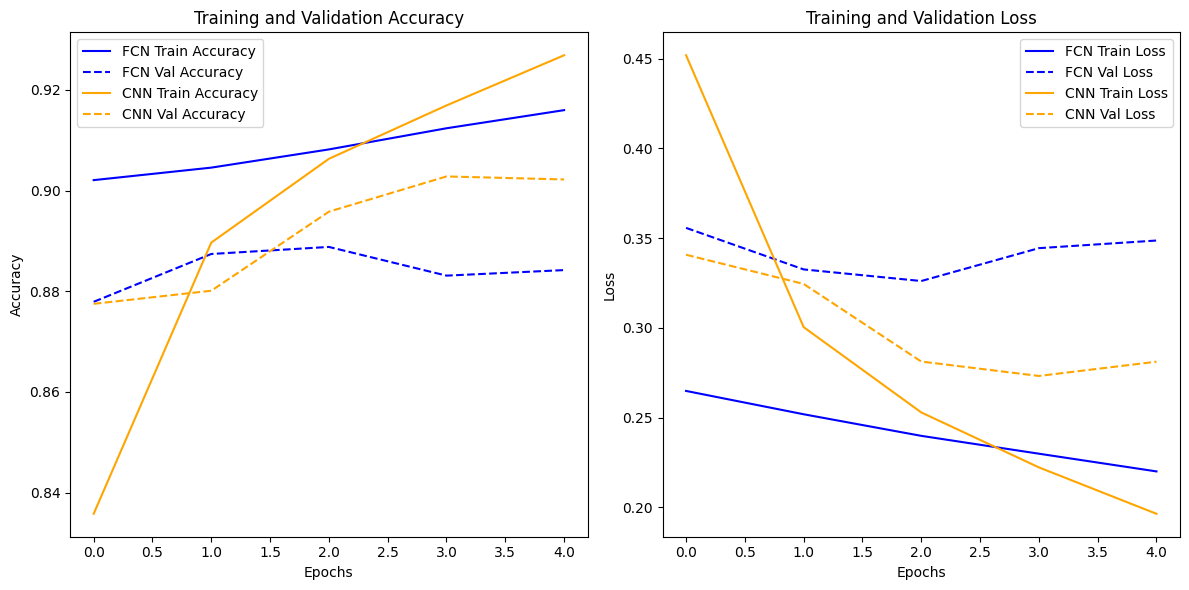

In [ ]:
import matplotlib.pyplot as plt

fcn_history = {
    'train_acc': history.history['accuracy'],
    'val_acc': history.history['val_accuracy'],
    'train_loss': history.history['loss'],
    'val_loss': history.history['val_loss']
}

cnn_history = cnn_model.history.history

plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.plot(fcn_history['train_acc'], label='FCN Train Accuracy', color='blue')
plt.plot(fcn_history['val_acc'], label='FCN Val Accuracy', color='blue', linestyle='dashed')
plt.plot(cnn_history['accuracy'], label='CNN Train Accuracy', color='orange')
plt.plot(cnn_history['val_accuracy'], label='CNN Val Accuracy', color='orange', linestyle='dashed')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Training and Validation Accuracy')
plt.legend()
plt.subplot(1, 2, 2)
plt.plot(fcn_history['train_loss'], label='FCN Train Loss', color='blue')
plt.plot(fcn_history['val_loss'], label='FCN Val Loss', color='blue', linestyle='dashed')
plt.plot(cnn_history['loss'], label='CNN Train Loss', color='orange')
plt.plot(cnn_history['val_loss'], label='CNN Val Loss', color='orange', linestyle='dashed')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()

plt.tight_layout()
plt.show()

3)Implement a ResNet-34 CNN model using Keras

In [ ]:
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, Flatten, Input

base_model = ResNet50(weights=None, include_top=False, input_tensor=Input(shape=(224, 224, 3)))

x = Flatten()(base_model.output)
x = Dense(512, activation="relu")(x)
x = Dense(10, activation="softmax")(x)

resnet34_model = Model(inputs=base_model.input, outputs=x)

resnet34_model.compile(optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"])

In [ ]:
import tensorflow as tf
import tensorflow_datasets as tfds
from tensorflow.keras.applications import Xception
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, Flatten, GlobalAveragePooling2D
from tensorflow.keras.optimizers import Adam

dataset, info = tfds.load("tf_flowers", as_supervised=True, with_info=True)
train_ds, val_ds, test_ds = tfds.load("tf_flowers",
                                      split=['train[:70%]', 'train[70%:85%]', 'train[85%:]'],
                                      as_supervised=True)

def preprocess(image, label):
    image = tf.image.resize(image, (224, 224)) / 255.0
    return image, label

train_ds = train_ds.map(preprocess).batch(32).prefetch(1)
val_ds = val_ds.map(preprocess).batch(32).prefetch(1)
test_ds = test_ds.map(preprocess).batch(32).prefetch(1)

base_model = Xception(weights="imagenet", include_top=False, input_shape=(224, 224, 3))
base_model.trainable = False

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(256, activation="relu")(x)
x = Dense(5, activation="softmax")(x)

xception_model = Model(inputs=base_model.input, outputs=x)


xception_model.compile(optimizer=Adam(learning_rate=0.001),
                       loss="sparse_categorical_crossentropy",
                       metrics=["accuracy"])
xception_model.fit(train_ds, validation_data=val_ds, epochs=5)

Dl Completed...: 0 url [00:00, ? url/s]

Dl Size...: 0 MiB [00:00, ? MiB/s]

Generating splits...:   0%|          | 0/1 [00:00<?, ? splits/s]

Generating train examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/tf_flowers/incomplete.0STG8M_3.0.1/tf_flowers-train.tfrecord*...:   0%|   …

Dataset tf_flowers downloaded and prepared to /root/tensorflow_datasets/tf_flowers/3.0.1. Subsequent calls will reuse this data.
83683744/83683744 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
Epoch 1/5
81/81 ━━━━━━━━━━━━━━━━━━━━ 819s 10s/step - accuracy: 0.7295 - loss: 0.7019 - val_accuracy: 0.8947 - val_loss: 0.3077
Epoch 2/5
81/81 ━━━━━━━━━━━━━━━━━━━━ 800s 10s/step - accuracy: 0.9090 - loss: 0.2682 - val_accuracy: 0.8893 - val_loss: 0.2946
Epoch 3/5
81/81 ━━━━━━━━━━━━━━━━━━━━ 796s 10s/step - accuracy: 0.9457 - loss: 0.1760 - val_accuracy: 0.8784 - val_loss: 0.2996
Epoch 4/5
81/81 ━━━━━━━━━━━━━━━━━━━━ 859s 11s/step - accuracy: 0.9726 - loss: 0.1180 - val_accuracy: 0.9020 - val_loss: 0.2838
Epoch 5/5
81/81 ━━━━━━━━━━━━━━━━━━━━ 790s 10s/step - accuracy: 0.9801 - loss: 0.0844 - val_accuracy: 0.8838 - val_loss: 0.3578


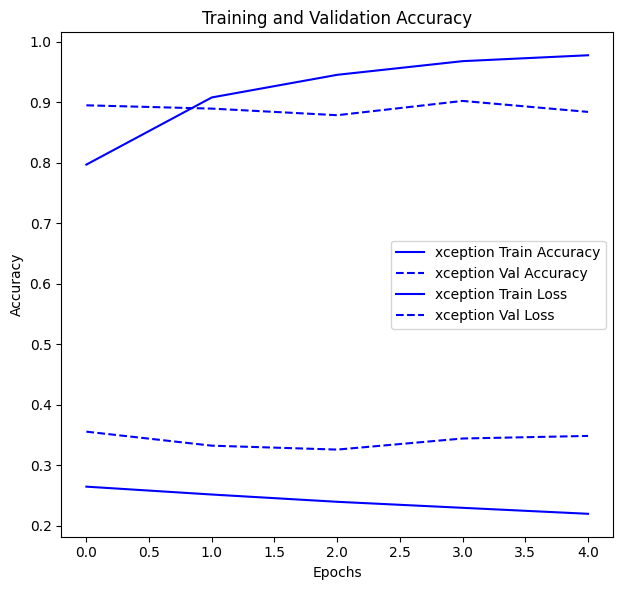

In [ ]:
xception_history = {
    'train_acc': xception_model.history.history['accuracy'],
    'val_acc': xception_model.history.history['val_accuracy'],
    'train_loss': xception_model.history.history['loss'],
    'val_loss': xception_model.history.history['val_loss']
}
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.plot(xception_history['train_acc'], label='xception Train Accuracy', color='blue')
plt.plot(xception_history['val_acc'], label='xception Val Accuracy', color='blue', linestyle='dashed')
plt.plot(fcn_history['train_loss'], label='xception Train Loss', color='blue')
plt.plot(fcn_history['val_loss'], label='xception Val Loss', color='blue', linestyle='dashed')

plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Training and Validation Accuracy')
plt.legend()

plt.tight_layout()
plt.show()